# Class Imbalance Ablation: DistilBERT

Compare model performance when trained on the original imbalanced dataset (~20% toxic) vs. a balanced dataset (50/50 undersample). Both models are evaluated on the same imbalanced test set.

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path("../../../..").resolve()
DATA_DIR = Path("data")
MODEL_TYPE = "transformer"
GLOBAL_MODEL_DIR = ROOT / "data" / "models" / MODEL_TYPE

ABLATION_DIR = DATA_DIR / "balanced"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

assert GLOBAL_MODEL_DIR.exists() and (GLOBAL_MODEL_DIR / "data_splits.pkl").exists(), (
    f"Global model not found at {GLOBAL_MODEL_DIR}. "
    f"Train it first:\n  python -m model.train --model {MODEL_TYPE} "
    f"--data data/train_dataset_clean.csv --output {GLOBAL_MODEL_DIR}"
)

## 1. Baseline (global model)

In [2]:
if not (GLOBAL_MODEL_DIR / "evaluation_results.json").exists():
    !cd {ROOT} && python3 -m model.evaluate --model {MODEL_TYPE} --model-dir {GLOBAL_MODEL_DIR}

with open(GLOBAL_MODEL_DIR / "evaluation_results.json") as f:
    results_baseline = json.load(f)

print(f"Baseline threshold: {results_baseline['best_threshold']:.2f}")
for m, v in results_baseline['quality_tuned'].items():
    print(f"  {m:15s}: {v:.4f}")

Baseline threshold: 0.53
  precision      : 0.9430
  recall         : 0.9208
  f1_score       : 0.9318
  pr_auc         : 0.9781


## 2. Train & Evaluate (balanced)

In [3]:
if not (ABLATION_DIR / "evaluation_results.json").exists():
    with open(GLOBAL_MODEL_DIR / "data_splits.pkl", "rb") as f:
        splits = pickle.load(f)

    X_train, y_train = splits['X_train'], splits['y_train']
    toxic_idx = np.where(y_train == 1)[0]
    safe_idx = np.where(y_train == 0)[0]
    rng = np.random.RandomState(SEED)
    safe_sampled = rng.choice(safe_idx, size=len(toxic_idx), replace=False)
    bal_idx = np.concatenate([safe_sampled, toxic_idx])
    rng.shuffle(bal_idx)

    balanced_splits = {
        'X_train': X_train[bal_idx], 'y_train': y_train[bal_idx],
        'X_val': splits['X_val'], 'y_val': splits['y_val'],
        'X_test': splits['X_test'], 'y_test': splits['y_test'],
    }
    splits_path = ABLATION_DIR / "data_splits.pkl"
    with open(splits_path, "wb") as f:
        pickle.dump(balanced_splits, f)
    print(f"Balanced train: {len(bal_idx)} samples ({balanced_splits['y_train'].mean():.0%} toxic)")

    !cd {ROOT} && python3 -m model.train --model {MODEL_TYPE} --data-splits {splits_path.resolve()} --output {ABLATION_DIR.resolve()}
    !cd {ROOT} && python3 -m model.evaluate --model {MODEL_TYPE} --model-dir {ABLATION_DIR.resolve()}
else:
    print(f"Results already exist in {ABLATION_DIR}, skipping.")

Balanced train: 132964 samples (50% toxic)
Loading data splits from /Users/narly/Code/Study/S26/GENAI/GenAI-Safety-Fliter/model/experiments/transformer/class_imbalance/data/balanced/data_splits.pkl...
Train: 132964, Val: 36825, Test: 92061
Train toxicity rate: 50.00%
Device: mps
Loading weights: 100%|█| 100/100 [00:00<00:00, 5346.20it/s, Materializing param=
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 3. Load Results

In [4]:
with open(ABLATION_DIR / "evaluation_results.json") as f:
    results_ablation = json.load(f)

print("Baseline results loaded:", list(results_baseline.keys()))
print("Ablation results loaded:", list(results_ablation.keys()))

Baseline results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']
Ablation results loaded: ['quality', 'confusion_matrix', 'latency', 'throughput_samples_per_sec', 'peak_memory_mb', 'quality_tuned', 'best_threshold', 'confusion_matrix_tuned']


## 4. Comparison

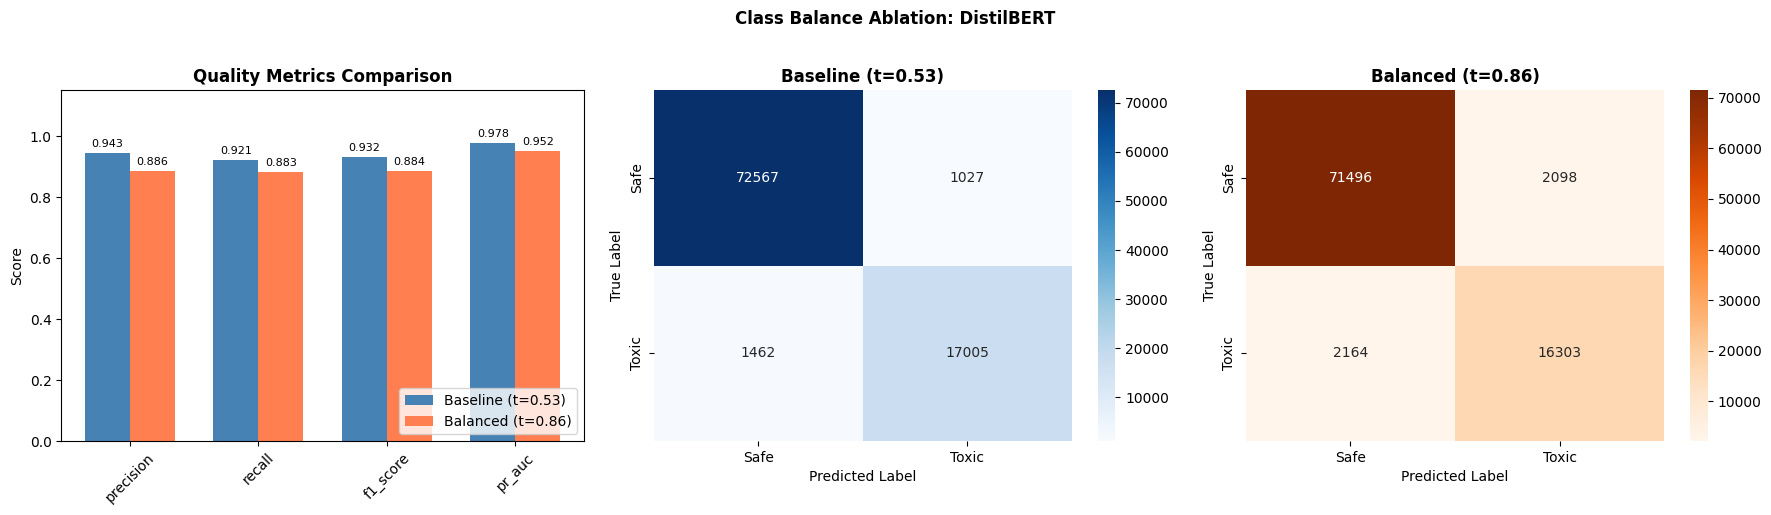


CLASS BALANCE ABLATION SUMMARY (tuned thresholds)
Metric              Baseline     Balanced      Delta
--------------------------------------------------
precision             0.9430       0.8860    -0.0571
recall                0.9208       0.8828    -0.0380
f1_score              0.9318       0.8844    -0.0474
pr_auc                0.9781       0.9519    -0.0262
--------------------------------------------------
Threshold               0.53         0.86


In [5]:
metrics_names = ['precision', 'recall', 'f1_score', 'pr_auc']
base_vals = [results_baseline['quality_tuned'][m] for m in metrics_names]
abl_vals = [results_ablation['quality_tuned'][m] for m in metrics_names]
t_base = results_baseline['best_threshold']
t_abl = results_ablation['best_threshold']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(metrics_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, base_vals, width,
                     label=f'Baseline (t={t_base:.2f})', color='steelblue')
bars2 = axes[0].bar(x + width/2, abl_vals, width,
                     label=f'Balanced (t={t_abl:.2f})', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Quality Metrics Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, rotation=45)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1.15)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.02, f'{h:.3f}',
                 ha='center', fontsize=8)

cm_base = np.array(results_baseline['confusion_matrix_tuned'])
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[1].set_title(f'Baseline (t={t_base:.2f})', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

cm_abl = np.array(results_ablation['confusion_matrix_tuned'])
sns.heatmap(cm_abl, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['Safe', 'Toxic'], yticklabels=['Safe', 'Toxic'])
axes[2].set_title(f'Balanced (t={t_abl:.2f})', fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.suptitle('Class Balance Ablation: DistilBERT', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CLASS BALANCE ABLATION SUMMARY (tuned thresholds)")
print("=" * 70)
print(f"{'Metric':<15} {'Baseline':>12} {'Balanced':>12} {'Delta':>10}")
print("-" * 50)
for m in metrics_names:
    bv = results_baseline['quality_tuned'][m]
    av = results_ablation['quality_tuned'][m]
    delta = av - bv
    print(f"{m:<15} {bv:>12.4f} {av:>12.4f} {delta:>+10.4f}")
print("-" * 50)
print(f"{'Threshold':<15} {t_base:>12.2f} {t_abl:>12.2f}")